# Đề tài 4 — Notebook 01: Chuẩn bị dữ liệu và thống kê mô tả

**Bài toán.** Phát hiện việc đội mũ bảo hiểm (helmet detection) — một trong các bài toán được liệt kê trong đề tài, có dữ liệu công khai và rất sát bối cảnh giao thông / công trường ở Việt Nam.

**Dữ liệu.** `andrewmvd/hard-hat-detection` (Safety Helmet Detection) — **5.000 ảnh**, nhãn ở định dạng **PASCAL VOC XML**, 3 lớp:

| id | lớp | ý nghĩa |
|---|---|---|
| 0 | `helmet` | đầu người **có** đội mũ bảo hiểm |
| 1 | `head` | đầu người **không** đội mũ |
| 2 | `person` | người ở dạng toàn thân (lớp hiếm) |

Bộ này thỏa mãn ràng buộc *"giới hạn ≤ 5.000 ảnh"* của đề bài, và quan trọng hơn: nhãn gốc **không** ở định dạng YOLO, nên ta thực sự phải thực hiện bước chuẩn hóa mà đề bài yêu cầu (chứ không tải sẵn một bộ đã ở dạng YOLO rồi bỏ qua bước này).

---

"Chuẩn hóa dữ liệu về định dạng YOLO, chia train/val/test, thống kê phân bố lớp và phân bố kích thước hộp (small/medium/large)."

| Mục trong notebook | Nội dung yêu cầu |
|---|---|
| §2–§3 | Đọc nhãn VOC, chuyển sang định dạng YOLO (chuẩn hóa toạ độ về `[0,1]`) |
| §4 | Chia train/val/test **có phân tầng**, seed cố định |
| §5 | Thống kê phân bố lớp theo từng tập |
| §6 | Thống kê phân bố kích thước hộp theo quy ước COCO (small/medium/large) |
| §7–§8 | Sinh `data.yaml`, kiểm tra tính toàn vẹn, lưu bảng số liệu cho báo cáo |


## 0. Thiết lập môi trường

In [2]:
# Nếu chạy lần đầu, bỏ comment dòng dưới (xem thêm requirements.txt)
# %pip install -q ultralytics kagglehub pandas matplotlib seaborn pillow tqdm pyyaml

import sys, os, time, json, shutil
from pathlib import Path

# cho phép import các module trong src/ khi notebook nằm ở notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import config
from config import (
    RAW_DIR, YOLO_DIR, ARTIFACT_DIR, DATA_YAML, CLASS_NAMES, CLASS_NAMES_VI,
    SPLITS, SPLIT_RATIOS, SEED, set_seed, describe_environment,
)
import data_utils as du

set_seed(SEED)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

env = describe_environment()
print(json.dumps(env, indent=2, ensure_ascii=False))
print("\nPROJECT_ROOT =", PROJECT_ROOT)

{
  "python": "3.10.20",
  "platform": "Linux-7.0.0-28-generic-x86_64-with-glibc2.39",
  "seed": 42,
  "torch": "2.7.1+cu126",
  "cuda_available": true,
  "gpu": "NVIDIA GeForce RTX 4090",
  "cuda": "12.6",
  "vram_gb": 23.5,
  "ultralytics": "8.3.40"
}

PROJECT_ROOT = /home/lablee/Documents/wm/projectdl


> **Ghi chú về tái lập.** `set_seed(42)` cố định `random`, `numpy` và `torch` (bao gồm `cudnn.deterministic=True`). Toàn bộ phép chia tập ở §4 dùng `np.random.default_rng(SEED)` chứ không dùng biến toàn cục, nên chạy lại notebook ở bất kỳ thứ tự cell nào cũng cho ra **đúng cùng một phép chia**. Hãy chụp lại output của cell trên và đưa vào phụ lục báo cáo — đó là bằng chứng môi trường.

## 1. Tải dữ liệu gốc

Hai cách, chọn một:

**Cách A — tự động qua `kagglehub`** (cần đăng nhập Kaggle một lần: đặt file `~/.kaggle/kaggle.json`).

**Cách B — tải tay** từ <https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection>, giải nén sao cho có:

```
data/raw/
├── images/       # 5000 file .png
└── annotations/  # 5000 file .xml
```

Cell dưới thử cách A trước, nếu hỏng thì hướng dẫn làm cách B. Sau khi có dữ liệu, **không bao giờ sửa `data/raw/`** — mọi biến đổi đều ghi ra `data/yolo/`.

In [3]:
IMG_SRC = RAW_DIR / "images"
ANN_SRC = RAW_DIR / "annotations"

def _looks_ready() -> bool:
    return IMG_SRC.is_dir() and ANN_SRC.is_dir() and any(ANN_SRC.glob("*.xml"))

if not _looks_ready():
    try:
        import kagglehub
        print("Đang tải qua kagglehub (lần đầu có thể mất vài phút)...")
        cache = Path(kagglehub.dataset_download(config.KAGGLE_DATASET))
        print("Đã tải về cache:", cache)

        # bộ dữ liệu này có thể lồng thêm 1 cấp thư mục -> dò tìm cho chắc
        src_img = next(p for p in cache.rglob("*") if p.is_dir() and p.name == "images")
        src_ann = next(p for p in cache.rglob("*") if p.is_dir() and p.name == "annotations")
        RAW_DIR.mkdir(parents=True, exist_ok=True)
        for src, dst in [(src_img, IMG_SRC), (src_ann, ANN_SRC)]:
            if not dst.exists():
                shutil.copytree(src, dst)
        print("Đã sao chép vào", RAW_DIR)
    except Exception as e:
        raise SystemExit(
            f"Không tải tự động được ({type(e).__name__}: {e}).\n"
            f"Hãy tải tay và giải nén vào:\n"
            f"  {IMG_SRC}\n  {ANN_SRC}\n"
            f"Nguồn: https://www.kaggle.com/datasets/{config.KAGGLE_DATASET}"
        )

xml_files = sorted(ANN_SRC.glob("*.xml"))
img_files = sorted([p for p in IMG_SRC.iterdir()
                    if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])
print(f"Số file nhãn XML : {len(xml_files)}")
print(f"Số file ảnh      : {len(img_files)}")
assert len(xml_files) > 0, "Chưa thấy file XML nào — kiểm tra lại đường dẫn."

Đang tải qua kagglehub (lần đầu có thể mất vài phút)...


100%|██████████████████████████████████████████████████████████| 1.22G/1.22G [02:09<00:00, 10.1MB/s]

Extracting files...


Đã tải về cache: /home/lablee/.cache/kagglehub/datasets/andrewmvd/hard-hat-detection/versions/1
Đã sao chép vào /home/lablee/Documents/wm/data/raw
Số file nhãn XML : 5000
Số file ảnh      : 5000


## 2. Khảo sát định dạng nhãn gốc

Trước khi viết bộ chuyển đổi, phải nhìn tận mắt một file nhãn. Đây là bước hay bị bỏ qua và là nguyên nhân phổ biến nhất khiến mô hình "train được nhưng mAP bằng 0": toạ độ sai hệ quy chiếu mà không ai phát hiện.

In [4]:
print("=== Nội dung một file annotation VOC ===")
print(xml_files[0].read_text(encoding="utf-8")[:1200])

=== Nội dung một file annotation VOC ===

<annotation>
    <folder>images</folder>
    <filename>hard_hat_workers0.png</filename>
    <size>
        <width>416</width>
        <height>416</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>357</xmin>
            <ymin>116</ymin>
            <xmax>404</xmax>
            <ymax>175</ymax>
        </bndbox>
    </object>
    <object>
        <name>helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>4</xmin>
            <ymin>146</ymin>
            <xmax>39</xmax>
            <ymax>184</ymax>
        </bndbox>
    </object>
    <object>
        <name>helmet</name>
        <pose>Unspecified</

**Chuẩn hóa định dạng của datatset**

| | PASCAL VOC (gốc) | YOLO (đích) |
|---|---|---|
| Đơn vị | pixel tuyệt đối | chuẩn hóa về `[0, 1]` theo `W`, `H` của ảnh |
| Cách mô tả hộp | 2 góc: `xmin, ymin, xmax, ymax` | tâm + kích thước: `cx, cy, w, h` |
| Lớp | chuỗi (`"helmet"`) | số nguyên (`0`) |
| Lưu trữ | 1 file `.xml` / ảnh | 1 file `.txt` / ảnh, mỗi dòng 1 hộp |

Công thức chuyển đổi (được cài trong `data_utils.voc_to_yolo_lines`):

$$c_x=\frac{x_{\min}+x_{\max}}{2W},\quad c_y=\frac{y_{\min}+y_{\max}}{2H},\quad w=\frac{x_{\max}-x_{\min}}{W},\quad h=\frac{y_{\max}-y_{\min}}{H}$$

In [5]:
# Đọc toàn bộ 5.000 file nhãn (mất ~10-20 giây)
records = [du.parse_voc_xml(p) for p in tqdm(xml_files, desc="Đọc VOC XML")]
records_by_stem = {r["stem"]: r for r in records}

# Ánh xạ stem -> đường dẫn ảnh; loại các annotation không có ảnh tương ứng
image_lookup = {p.stem: p for p in img_files}
missing = [s for s in records_by_stem if s not in image_lookup]
if missing:
    print(f"CẢNH BÁO: {len(missing)} annotation không có ảnh -> loại bỏ. Ví dụ: {missing[:5]}")
    for s in missing:
        records_by_stem.pop(s)
    records = list(records_by_stem.values())

print(f"Số ảnh dùng được: {len(records)}")

# Kiểm tra tên lớp thực tế có khớp với CLASS_NAMES đã khai báo không
from collections import Counter
raw_names = Counter(o["name"] for r in records for o in r["objects"])
print("\nTên lớp xuất hiện trong dữ liệu gốc:")
for k, v in raw_names.most_common():
    flag = "OK" if k in CLASS_NAMES else "  <-- KHÔNG nằm trong CLASS_NAMES, sẽ bị loại"
    print(f"  {k:<12} {v:>7,}  {flag}")

Đọc VOC XML:   0%|          | 0/5000 [00:00<?, ?it/s]

Số ảnh dùng được: 5000

Tên lớp xuất hiện trong dữ liệu gốc:
  helmet        18,966  OK
  head           5,785  OK
  person           751  OK


`Số ảnh dùng được: 5000` — không có annotation nào mồ côi.

Bảng tên lớp là một **chốt chặn quan trọng**: nó đối chiếu tên lớp *thực có trong dữ liệu* với `CLASS_NAMES` *ta khai báo trong config*. Cả ba dòng đều `OK`, nghĩa là không có lớp lạ nào bị âm thầm vứt đi.

```
helmet   18.966
head      5.785
person       751
        ────────
tổng     25.502
```

Đây là lần đầu tiên **mức mất cân bằng** lộ ra: `helmet` nhiều gấp 25 lần `person`. Ghi nhớ con số này, §5 sẽ định lượng chính xác.

In [6]:
# DataFrame mức-đối-tượng: mỗi dòng là một bounding box. Đây là "nguồn sự thật"
# cho mọi thống kê ở §5, §6 và cho phân tích lỗi ở notebook 04.
ann_df = du.build_annotation_dataframe(records)
ann_df = ann_df[ann_df["class"].isin(CLASS_NAMES)].reset_index(drop=True)

print(f"Tổng số bounding box: {len(ann_df):,}")
print(f"Số ảnh              : {ann_df['stem'].nunique():,}")
print(f"Kích thước ảnh      : {ann_df['img_w'].min()}x{ann_df['img_h'].min()} "
      f"→ {ann_df['img_w'].max()}x{ann_df['img_h'].max()}")
ann_df.head()

Tổng số bounding box: 25,502
Số ảnh              : 5,000
Kích thước ảnh      : 415x415 → 416x416


,stem,img_w,img_h,class,xmin,ymin,xmax,ymax,box_w,box_h,area_px,area_frac,aspect,cx_norm,cy_norm,size_bucket
0,hard_hat_workers0,416,416,helmet,357.0,116.0,404.0,175.0,47.0,59.0,2773.0,0.016024,0.796610,0.914663,0.349760,medium
1,hard_hat_workers0,416,416,helmet,4.0,146.0,39.0,184.0,35.0,38.0,1330.0,0.007685,0.921053,0.051683,0.396635,medium
2,hard_hat_workers0,416,416,helmet,253.0,139.0,275.0,177.0,22.0,38.0,836.0,0.004831,0.578947,0.634615,0.379808,small
3,hard_hat_workers0,416,416,helmet,300.0,145.0,323.0,181.0,23.0,36.0,828.0,0.004785,0.638889,0.748798,0.391827,small
4,hard_hat_workers0,416,416,helmet,116.0,151.0,138.0,180.0,22.0,29.0,638.0,0.003687,0.758621,0.305288,0.397837,small




`25.502` hộp trên `5.000` ảnh → trung bình **5,10 hộp/ảnh**. Đây là bộ dữ liệu **cảnh đông**, không phải mỗi ảnh một vật thể. Hệ quả trực tiếp: ngưỡng NMS sẽ là tham số nhạy cảm ở notebook 02 §5.

Dòng kích thước ảnh in ra `415x415 → 416x416`: gần như toàn bộ là 416×416, nhưng có vài ảnh lệch 1 pixel. Vô hại, nhưng đây chính là lý do công thức chuẩn hoá phải chia cho `W`, `H` **của từng ảnh** chứ không hardcode 416.

Nhìn bảng `head()`: hộp đầu tiên có `area_px = 2773` → thuộc nhóm `medium`; hộp thứ ba `area_px = 836` → `small`. Ngưỡng phân nhóm là 32² = 1024 px², xem §6.

DataFrame này là **nguồn sự thật duy nhất** cho mọi thống kê phía sau, và được lưu ra `annotations.parquet` ở §8 để notebook 04 dùng lại — khỏi phải đọc lại 5.000 file XML.

## 3–4. Chia tập có phân tầng, rồi ghi ra định dạng YOLO

**Vì sao không chia ngẫu nhiên thuần túy?** Lớp `person` rất hiếm (xem §5). Với một phép hoán vị ngẫu nhiên, số ảnh chứa `person` rơi vào tập test có thể dao động mạnh giữa các seed, khiến `AP(person)` gần như là nhiễu và mọi so sánh sau này mất ý nghĩa.

Vì vậy ta phân tầng theo khóa `(lớp-hiếm-nhất-có-trong-ảnh, nhóm-số-lượng-đối-tượng)`. Cách này giữ cho cả 3 tập có **phân bố lớp** và **mật độ đối tượng/ảnh** tương đương nhau — đây chính là điều kiện "thí nghiệm công bằng" mà thang điểm yêu cầu.

Tỉ lệ chia: **70% train / 15% val / 15% test**. Tập `test` chỉ được chạm vào **một lần duy nhất** ở cuối notebook 02; mọi việc chọn ngưỡng, chọn siêu tham số đều làm trên `val`.

In [7]:
split_stems = du.stratified_split(records, ratios=SPLIT_RATIOS, seed=SEED)
for s in SPLITS:
    print(f"{s:<6}: {len(split_stems[s]):>5,} ảnh  ({len(split_stems[s])/len(records):.1%})")

# Kiểm tra chốt chặn: 3 tập phải rời nhau hoàn toàn (không rò rỉ dữ liệu)
sets = {s: set(v) for s, v in split_stems.items()}
assert not (sets["train"] & sets["val"]), "Rò rỉ train/val!"
assert not (sets["train"] & sets["test"]), "Rò rỉ train/test!"
assert not (sets["val"] & sets["test"]), "Rò rỉ val/test!"
assert sum(len(v) for v in sets.values()) == len(records)
print("\n✔ Ba tập rời nhau, không có rò rỉ dữ liệu.")

train : 3,501 ảnh  (70.0%)
val   :   750 ảnh  (15.0%)
test  :   749 ảnh  (15.0%)

✔ Ba tập rời nhau, không có rò rỉ dữ liệu.


**Code làm gì.** Gọi `stratified_split()` rồi **tự kiểm tra bằng `assert`** rằng ba tập rời nhau hoàn toàn.

**Output nói gì.** `3.501 / 750 / 749` ảnh — đúng 70,0% / 15,0% / 15,0%. Phân tầng không làm lệch tỉ lệ tổng.

Bốn dòng `assert` là phần quan trọng nhất của cell này dù không in ra gì khi thành công. Chúng loại trừ **rò rỉ dữ liệu** (data leakage): nếu một ảnh xuất hiện ở cả `train` và `test`, mô hình sẽ được chấm trên chính thứ nó đã học thuộc, và mọi chỉ số đều vô nghĩa. Dòng `✔ Ba tập rời nhau` là bằng chứng điều đó không xảy ra — đáng nhắc tới trong mục *Dữ liệu* của báo cáo.

In [8]:
# Ghi ra cây thư mục mà ultralytics yêu cầu:
#   data/yolo/images/{train,val,test}/*.png
#   data/yolo/labels/{train,val,test}/*.txt
# Trên Windows nếu symlink lỗi, đổi copy_mode="copy".
t0 = time.time()
split_summary = du.materialize_yolo_dataset(
    records_by_stem=records_by_stem,
    split_stems=split_stems,
    image_lookup=image_lookup,
    out_dir=YOLO_DIR,
    copy_mode="symlink",
)
print(f"Hoàn tất trong {time.time()-t0:.1f}s\n")
split_summary

Hoàn tất trong 0.6s



,n_images,n_boxes,boxes_per_image,n_empty_images,n_boxes_dropped
split,,,,,
train,3501,17783,5.08,0,0
val,750,3867,5.16,0,0
test,749,3852,5.14,0,0


 Bảng tổng kết có bốn cột đáng đọc:

| cột | giá trị | ý nghĩa |
|---|---|---|
| `boxes_per_image` | 5,08 / 5,16 / 5,14 | mật độ đối tượng **gần như bằng nhau** giữa ba tập |
| `n_boxes_dropped` | 0 / 0 / 0 | không hộp nào bị loại vì suy biến hay sai lớp |
| `n_empty_images` | 0 / 0 / 0 | không ảnh nào không có đối tượng |
| `n_boxes` | 17.783 / 3.867 / 3.852 | cộng lại đúng 25.502 |

Cột `boxes_per_image` là **bằng chứng thứ hai cho phép phân tầng**: khoá phân tầng gồm cả thành phần "nhóm số lượng đối tượng", nên không chỉ tỉ lệ lớp mà cả *mật độ cảnh* cũng đồng đều. Nếu tập test toàn ảnh thưa còn train toàn ảnh đông, so sánh sẽ không công bằng.

`Hoàn tất trong 0.6s` — nhanh vì symlink chỉ tạo con trỏ. Đánh đổi: cây `data/yolo/` **không tự chứa**, di chuyển thư mục `data/` là link gãy. Đổi sang `copy_mode="copy"` nếu cần mang dữ liệu đi nơi khác.

In [9]:
# Đối chiếu tận mắt: một nhãn VOC gốc và nhãn YOLO tương ứng sau chuyển đổi
demo_stem = split_stems["train"][0]
rec = records_by_stem[demo_stem]
print(f"Ảnh: {demo_stem}  ({rec['width']}x{rec['height']})\n")
print("--- VOC (pixel tuyệt đối) ---")
for o in rec["objects"][:5]:
    print(f"  {o['name']:<8} xmin={o['xmin']:.0f} ymin={o['ymin']:.0f} "
          f"xmax={o['xmax']:.0f} ymax={o['ymax']:.0f}")
print("\n--- YOLO (đã chuẩn hóa [0,1]) ---")
print((YOLO_DIR / "labels" / "train" / f"{demo_stem}.txt").read_text().strip() or "(ảnh không có đối tượng)")

Ảnh: hard_hat_workers0  (416x416)

--- VOC (pixel tuyệt đối) ---
  helmet   xmin=357 ymin=116 xmax=404 ymax=175
  helmet   xmin=4 ymin=146 xmax=39 ymax=184
  helmet   xmin=253 ymin=139 xmax=275 ymax=177
  helmet   xmin=300 ymin=145 xmax=323 ymax=181
  helmet   xmin=116 ymin=151 xmax=138 ymax=180

--- YOLO (đã chuẩn hóa [0,1]) ---
0 0.914663 0.349760 0.112981 0.141827
0 0.051683 0.396635 0.084135 0.091346
0 0.634615 0.379808 0.052885 0.091346
0 0.748798 0.391827 0.055288 0.086538
0 0.305288 0.397837 0.052885 0.069712
0 0.216346 0.397837 0.048077 0.069712
1 0.174279 0.379808 0.050481 0.067308
1 0.801683 0.383413 0.055288 0.088942
1 0.443510 0.411058 0.045673 0.072115
1 0.555288 0.400240 0.043269 0.074519
1 0.500000 0.383413 0.038462 0.064904
0 0.252404 0.360577 0.033654 0.048077
1 0.399038 0.393029 0.043269 0.064904


Đây là chỗ nên **kiểm tra lại bằng tay** một lần — làm được phép tính này là chứng minh hiểu bước chuyển đổi. Lấy hộp đầu tiên, `helmet` với `xmin=357 ymin=116 xmax=404 ymax=175`, ảnh 416×416:

```
cx = (357 + 404) / 2 / 416 = 380,5 / 416 = 0,914663  ✓
cy = (116 + 175) / 2 / 416 = 145,5 / 416 = 0,349760  ✓
w  = (404 − 357)     / 416 =    47 / 416 = 0,112981  ✓
h  = (175 − 116)     / 416 =    59 / 416 = 0,141827  ✓
```

Cả bốn số khớp **đúng đến chữ số thập phân thứ sáu** với dòng đầu của khối YOLO. Bộ chuyển đổi chạy đúng.

Để ý thêm: cột đầu mỗi dòng YOLO là class id — `0` = helmet, `1` = head. Ảnh này có 13 hộp gồm cả hai lớp, và **thứ tự dòng không quan trọng** đối với YOLO.

## 5. Thống kê phân bố lớp

Đây là bảng phải có trong báo cáo (mục *3. Dữ liệu*). Con số quan trọng cần nhìn: **tỉ lệ giữa lớp phổ biến nhất và lớp hiếm nhất**.

In [10]:
stem_to_split = {s: sp for sp, stems in split_stems.items() for s in stems}
ann_df["split"] = ann_df["stem"].map(stem_to_split)

cls_tab = du.class_distribution_table(ann_df)
display(cls_tab)

imb = cls_tab["total"].max() / cls_tab["total"].min()
print(f"\nTỉ lệ mất cân bằng lớp (nhiều nhất / ít nhất): {imb:.1f}×")
for c in CLASS_NAMES:
    print(f"  {c:<8} ({CLASS_NAMES_VI[c]:<18}): {cls_tab.loc[c,'total']:>7,} hộp")

,train,val,test,total,train_%,val_%,test_%
class,,,,,,,
helmet,13196,2860,2910,18966,74.21,73.96,75.55
head,4025,901,859,5785,22.63,23.30,22.30
person,562,106,83,751,3.16,2.74,2.15



Tỉ lệ mất cân bằng lớp (nhiều nhất / ít nhất): 25.3×
  helmet   (có đội mũ         ):  18,966 hộp
  head     (đầu trần          ):   5,785 hộp
  person   (người (toàn thân) ):     751 hộp


Đây là **bảng phải có trong mục *3. Dữ liệu*** của báo cáo. Hai cách đọc:

**Theo hàng — mức mất cân bằng.** `18.966 / 751 = 25,3×`. Mô hình sẽ thấy `helmet` nhiều gấp 25 lần `person` và gấp 3,3 lần `head`. Hệ quả cần nêu trước trong báo cáo, đừng để thành "kết quả bất ngờ": AP của lớp hiếm sẽ vừa thấp vừa dao động mạnh.

**Theo cột `%` — chất lượng phép chia.** Tỉ lệ `helmet` ở ba tập là **74,21% / 73,96% / 75,55%**, lệch chưa tới 1,6 điểm phần trăm. Phân tầng đã làm đúng việc của nó.

Một chi tiết cho phần phân tích: lớp có ý nghĩa nghiệp vụ nhất — `head`, tức người **không** đội mũ — lại chỉ chiếm 22,7% số hộp. Hệ thống sinh ra để tìm thứ hiếm hơn thứ nó hay gặp.

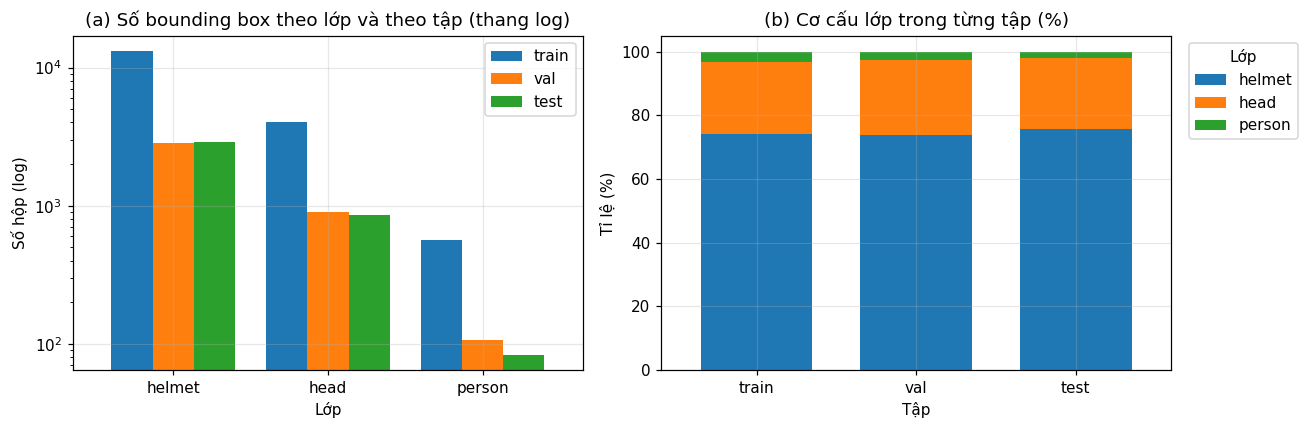

Cột (b) gần như bằng nhau giữa 3 tập → phép phân tầng ở §4 đã có tác dụng.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) số hộp theo lớp × tập, thang log vì chênh lệch rất lớn
cls_tab[list(SPLITS)].plot(kind="bar", ax=axes[0], logy=True, width=0.8)
axes[0].set_title("(a) Số bounding box theo lớp và theo tập (thang log)")
axes[0].set_xlabel("Lớp"); axes[0].set_ylabel("Số hộp (log)")
axes[0].tick_params(axis="x", rotation=0)

# (b) tỉ lệ phần trăm trong mỗi tập — dùng để chứng minh phép chia là cân bằng
pct = cls_tab[[f"{s}_%" for s in SPLITS]]
pct.columns = list(SPLITS)
pct.T.plot(kind="bar", stacked=True, ax=axes[1], width=0.7)
axes[1].set_title("(b) Cơ cấu lớp trong từng tập (%)")
axes[1].set_xlabel("Tập"); axes[1].set_ylabel("Tỉ lệ (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Lớp", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.savefig(ARTIFACT_DIR / "fig01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Cột (b) gần như bằng nhau giữa 3 tập → phép phân tầng ở §4 đã có tác dụng.")

**Panel (a) — cột đứng, trục tung là thang log.**

Trục hoành chia 3 nhóm cột theo lớp (`helmet`, `head`, `person`); mỗi nhóm có 3 cột màu (xanh dương = train, cam = val, xanh lá = test). Đọc chiều cao cột theo đúng vạch chia trên trục — vì là thang log nên khoảng cách bằng nhau trên trục dọc là gấp 10 lần, không phải cộng thêm cùng một lượng.

Nhìn ba cột xanh dương (train): cột `helmet` chạm gần mốc 10⁴ (~13.000), cột `head` nằm giữa 10³ và mốc dưới 10⁴ (~4.000), cột `person` chỉ nhỉnh hơn mốc 10² một chút (~560). Nếu vẽ bằng thang thường (tuyến tính), hai cột `head` và `person` sẽ tụt xuống gần sát trục hoành, gần như không phân biệt được độ chênh giữa chúng — đó là lý do bắt buộc dùng log ở đây.

**Panel (b) — cột chồng theo phần trăm, mỗi cột là một tập.**

Ba cột `train / val / test`, mỗi cột cao đúng 100% và được tô 3 màu chồng lên nhau theo tỉ lệ lớp. Nhìn bằng mắt: phần xanh dương (helmet) chiếm khoảng ba phần tư chiều cao ở cả ba cột, phần cam (head) khoảng một phần năm, phần xanh lá (person) chỉ là một dải mỏng sát đỉnh. Điểm cần thấy: ranh giới giữa các màu nằm ở gần như cùng một độ cao trên cả ba cột — nếu phân tầng thất bại, một trong ba cột sẽ có dải màu dày/mỏng khác hẳn hai cột kia. Ở đây không thấy sự lệch đó bằng mắt thường, khớp với con số đã tính ở bảng trên (chênh lệch dưới 1,6 điểm phần trăm).

## 6. Phân bố kích thước hộp (small / medium / large)

Ta dùng **quy ước COCO**, tính trên **ảnh gốc**:

| nhóm | diện tích hộp $A = w \times h$ |
|---|---|
| `small`  | $A < 32^2 = 1024$ px² |
| `medium` | $1024 \le A < 96^2 = 9216$ px² |
| `large`  | $A \ge 9216$ px² |

Bảng này **không chỉ để cho đẹp báo cáo**: toàn bộ phần *"phân tích lỗi định lượng ... thống kê theo kích thước vật thể"* ở notebook 04 sẽ dựa trên chính cách phân nhóm này. Nếu dữ liệu lệch hẳn về `small`, ta biết trước rằng độ phân giải đầu vào (§6 của notebook 02) sẽ là biến quan trọng nhất.

In [12]:
size_tab = du.size_distribution_table(ann_df)
display(size_tab)

overall = ann_df["size_bucket"].value_counts(normalize=True).reindex(
    ["small", "medium", "large"]) * 100
print("\nTrên toàn bộ dữ liệu:")
for k, v in overall.items():
    print(f"  {k:<7}: {v:5.1f}%")

size_bucket,small,medium,large,total,small_%,medium_%,large_%
class,,,,,,,
helmet,9795,8439,732,18966,51.6,44.5,3.9
head,3901,1865,19,5785,67.4,32.2,0.3
person,61,386,304,751,8.1,51.4,40.5



Trên toàn bộ dữ liệu:
  small  :  53.9%
  medium :  41.9%
  large  :   4.1%


Con số tổng: **53,9% small / 41,9% medium / 4,1% large**. Hơn nửa số đối tượng có cạnh tương đương dưới 32 pixel — đây là bộ dữ liệu **thiên hẳn về vật nhỏ**, và đó là đặc điểm chi phối mọi thứ phía sau.

Tách theo lớp thì bức tranh sắc nét hơn nhiều:

| lớp | small | large | đọc ra sao |
|---|---|---|---|
| `helmet` | 51,6% | 3,9% | cái mũ trên đầu — nhỏ |
| `head` | **67,4%** | 0,3% | **nhỏ nhất trong ba lớp** |
| `person` | 8,1% | **40,5%** | người toàn thân — lớn, ngược hẳn |

Hai kết luận mang thẳng sang phần *Phân tích*:

1. `head` vừa là lớp thiểu số, vừa là lớp **nhỏ nhất** → dự đoán có căn cứ rằng AP của nó thấp nhất và lỗi chủ đạo là **bỏ sót**. Nếu kết quả thật đúng như vậy, ta đã giải thích được *trước khi* nhìn số.
2. `person` có phân bố ngược hẳn → nó là bài toán khác về bản chất, không nên gộp chung khi bình luận.

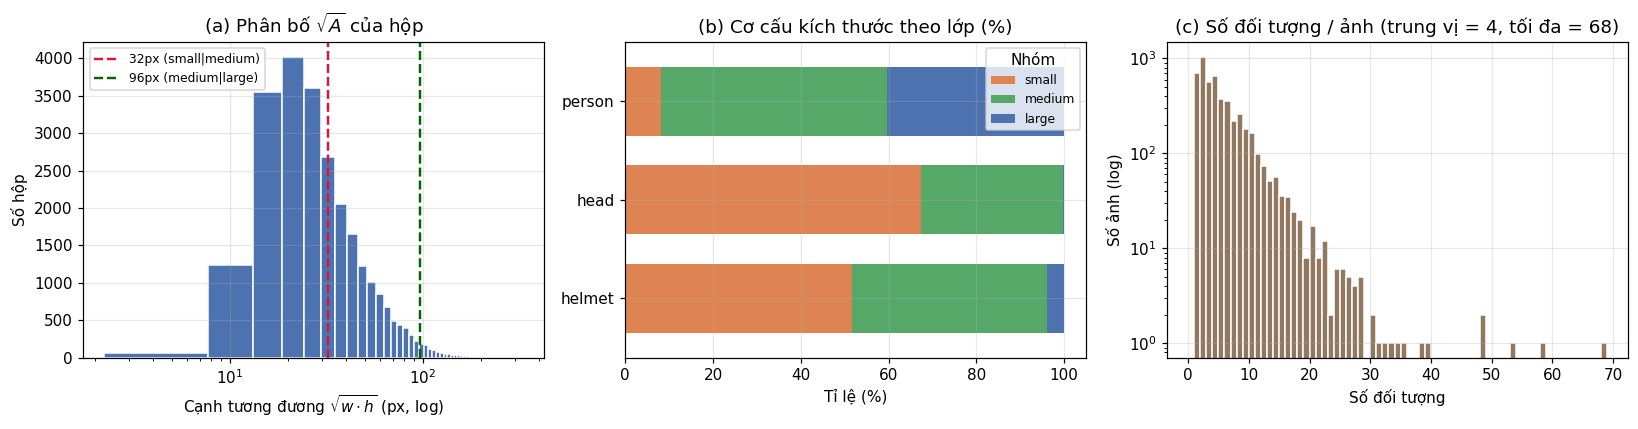

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) histogram diện tích, thang log
axes[0].hist(np.sqrt(ann_df["area_px"]), bins=60, color="#4C72B0", edgecolor="white")
for thr, lbl, col in [(32, "32px (small|medium)", "crimson"),
                      (96, "96px (medium|large)", "darkgreen")]:
    axes[0].axvline(thr, color=col, ls="--", lw=1.6, label=lbl)
axes[0].set_xscale("log")
axes[0].set_title("(a) Phân bố $\\sqrt{A}$ của hộp")
axes[0].set_xlabel("Cạnh tương đương $\\sqrt{w \\cdot h}$ (px, log)")
axes[0].set_ylabel("Số hộp"); axes[0].legend(fontsize=8)

# (b) tỉ lệ small/medium/large theo lớp
size_tab[["small", "medium", "large"]].div(
    size_tab["total"], axis=0).mul(100).plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#DD8452", "#55A868", "#4C72B0"], width=0.7)
axes[1].set_title("(b) Cơ cấu kích thước theo lớp (%)")
axes[1].set_xlabel("Tỉ lệ (%)"); axes[1].set_ylabel("")
axes[1].legend(title="Nhóm", fontsize=8)

# (c) số đối tượng trên mỗi ảnh
per_img = ann_df.groupby("stem").size()
axes[2].hist(per_img, bins=range(0, int(per_img.max()) + 2), color="#937860",
             edgecolor="white")
axes[2].set_yscale("log")
axes[2].set_title(f"(c) Số đối tượng / ảnh (trung vị = {per_img.median():.0f}, "
                  f"tối đa = {per_img.max()})")
axes[2].set_xlabel("Số đối tượng"); axes[2].set_ylabel("Số ảnh (log)")

plt.savefig(ARTIFACT_DIR / "fig02_box_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Panel (a) — histogram của căn bậc hai diện tích hộp, trục hoành thang log.**

Trục hoành không phải diện tích mà là cạnh của một hình vuông có cùng diện tích với hộp — ví dụ hộp 47×59 px có diện tích 2773 px², thì cạnh tương đương là căn(2773) xấp xỉ 52,7 px. Dùng cách quy đổi này vì "diện tích" là con số trừu tượng (2773 nghĩa là to hay nhỏ?), còn "52,7 px" thì hình dung được ngay — gần bằng chiều cao một dòng chữ trên ảnh.

Nhìn hình: khối cột cao nhất (~4.000 hộp) nằm ngay bên trái vạch đỏ 32px, tức phần lớn hộp trong dữ liệu có cạnh khoảng 15–30 px — rất nhỏ. Có một bậc thang rõ rệt ở khoảng 10px (cột ~1.200 hộp) rồi nhảy vọt lên đỉnh ngay sau đó. Từ đỉnh, cột giảm dần đều về bên phải, vượt qua vạch xanh lá 96px với chiều cao rất thấp, và kéo một cái đuôi dài mảnh tới tận vài trăm pixel (số hộp `person` cỡ lớn).

Đọc ra được gì: đỉnh phân bố nằm sát ngay bên trái ngưỡng small/medium — nghĩa là rất nhiều hộp nằm ở biên giới giữa hai nhóm. Chỉ cần nới ngưỡng 32px lên một chút, tỉ lệ small sẽ đổi đáng kể — nên khi trích dẫn con số 53,9% small trong báo cáo, nên ghi rõ đây là theo quy ước COCO, không phải một ranh giới tự nhiên của chính dữ liệu.

**Panel (b) — cột ngang chồng, theo phần trăm, mỗi hàng là một lớp.**

Ba hàng: `person`, `head`, `helmet`. Đọc theo chiều dài từng đoạn màu:

- Hàng `head` (giữa): đoạn cam (small) kéo dài tới hơn 2/3 chiều ngang — dài nhất trong ba hàng. Gần như không có đoạn xanh dương (large).
- Hàng `helmet` (dưới): đoạn cam ngắn hơn head một chút (khoảng nửa chiều ngang), đoạn xanh lá (medium) khá dài, có một mẩu xanh dương (large) nhỏ ở cuối.
- Hàng `person` (trên): gần như ngược hẳn hai hàng kia — đoạn cam rất ngắn (chỉ khoảng 8%), phần lớn là xanh lá và một đoạn xanh dương dài rõ rệt chiếm hơn 1/3 chiều dài hàng.

Ba hàng có hình dạng hoàn toàn khác nhau — đây là bằng chứng trực quan rằng `person` là một bài toán kích thước khác hẳn hai lớp kia, không nên gộp chung khi bàn về độ khó do vật thể nhỏ.

**Panel (c) — histogram số đối tượng mỗi ảnh, trục tung thang log.**

Tiêu đề hình đã ghi sẵn hai con số cần trích: trung vị = 4, tối đa = 68. Cột cao nhất nằm ở vài đối tượng đầu tiên (2–5 đối tượng/ảnh) với gần 1.000 ảnh, sau đó giảm dần đều đặn theo dạng bậc thang xuống đến khoảng 30 đối tượng, rồi rải rác vài cột lẻ tẻ ở tận 40, 50 và một cột đơn độc tại 68 — một tấm ảnh cực kỳ đông người so với phần còn lại của dữ liệu.

Đây chính là bằng chứng cho phần "phân bố lệch phải nặng": phần lớn ảnh chụp vài người, nhưng có một số rất ít ảnh chụp cả một công trường đông đúc. Ảnh 68-đối-tượng đó là ứng viên lý tưởng để minh họa ảnh hưởng của ngưỡng NMS ở notebook 02 §5 — càng đông đối tượng chồng lấn, ngưỡng NMS càng dễ gộp nhầm hai người đứng sát nhau.

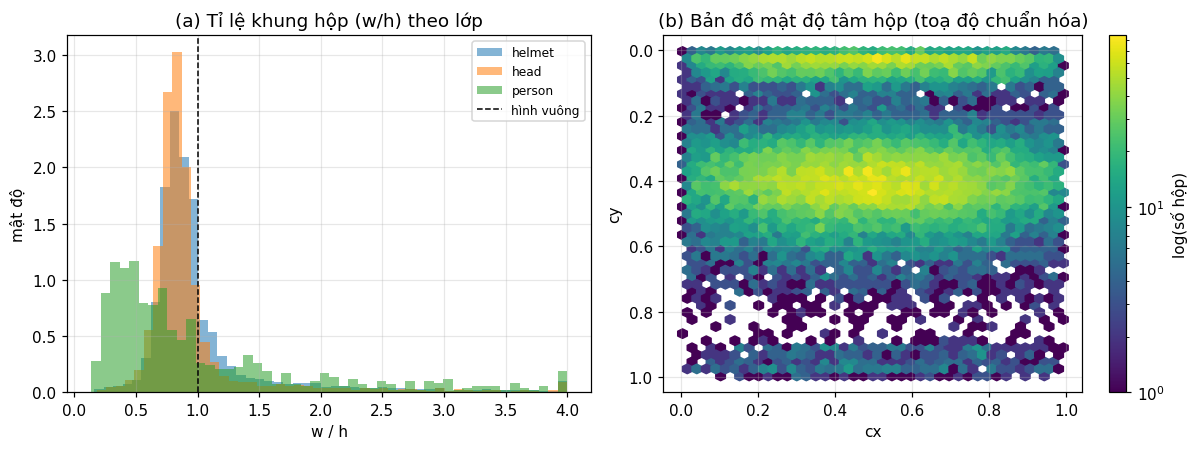

In [ ]:
# Hai hình bổ trợ, rất hữu ích khi biện luận ở phần Phân tích:
#  - tỉ lệ khung hộp  -> gợi ý về hình dạng anchor / prior
#  - vị trí tâm hộp   -> có thiên lệch không gian không?
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for c in CLASS_NAMES:
    sub = ann_df[ann_df["class"] == c]["aspect"].clip(0, 4)
    axes[0].hist(sub, bins=50, alpha=0.55, label=c, density=True)
axes[0].axvline(1.0, color="k", ls="--", lw=1, label="hình vuông")
axes[0].set_title("(a) Tỉ lệ khung hộp (w/h) theo lớp")
axes[0].set_xlabel("w / h"); axes[0].set_ylabel("mật độ"); axes[0].legend(fontsize=8)

hb = axes[1].hexbin(ann_df["cx_norm"], ann_df["cy_norm"], gridsize=40,
                    cmap="viridis", bins="log")
axes[1].invert_yaxis()
axes[1].set_title("(b) Bản đồ mật độ tâm hộp (toạ độ chuẩn hóa)")
axes[1].set_xlabel("cx"); axes[1].set_ylabel("cy")
plt.colorbar(hb, ax=axes[1], label="log(số hộp)")

plt.savefig(ARTIFACT_DIR / "fig03_aspect_and_center.png", dpi=150, bbox_inches="tight")
plt.show()

**Panel (a) — ba đường phân bố tỉ lệ khung (w/h) chồng lên nhau, có độ trong suốt.**

Đường màu xanh dương (helmet) và cam (head) gần như trùng khít nhau: cả hai đều đạt đỉnh ngay bên trái vạch đứt "hình vuông" (w/h = 1.0), khoảng 0,8–0,9. Nghĩa là hộp helmet/head hơi cao hơn rộng một chút, chứ không vuông tuyệt đối, hợp lý vì đầu người nhìn thẳng có dạng hơi bầu dục theo chiều dọc.

Đường màu xanh lá (person) có hình dạng khác hẳn hai đỉnh chứ không phải một:
- Đỉnh chính, cao và nhọn, nằm ở khoảng 0,3–0,4, hộp hẹp và rất cao, đúng dáng một người đứng thẳng được chụp toàn thân.
- Một đỉnh phụ nhỏ hơn ở vùng 2,5–4 tức là có một số hộp `person` lại rộng hơn cao nhiều lần. Đây là điểm đáng chú ý khi viết phần Hạn chế: có thể là người cúi/ngồi/nằm khi thao tác, hoặc một nhóm nhiều người bị gộp chung một hộp trong lúc gán nhãn gốc — cần mở vài ảnh cụ thể ở nhóm này ra kiểm tra trước khi kết luận.

**Panel (b) — bản đồ mật độ tâm hộp (hexbin), trục cy đã lật ngược để khớp chiều ảnh thật (0 = mép trên, 1 = mép dưới).**

Vùng sáng nhất (vàng) tập trung thành một dải ngang chạy gần hết chiều rộng ảnh, ở khoảng cy xấp xỉ 0,3 đến 0,55 — tức là hơi dưới chính giữa khung hình theo chiều dọc, chứ không dồn hẳn lên nửa trên như một số bộ ảnh chân dung thường thấy. Vùng gần mép trên (cy gần 0) và gần mép dưới (cy gần 1) thưa hẳn, chuyển sang màu tối/tím — ít tâm hộp rơi vào đó.

Theo chiều ngang (cx), dải sáng trải đều từ trái sang phải, không lệch hẳn về một bên — hợp lý với các ảnh chụp công trường có nhiều người dàn hàng ngang trong khung hình.

Ý nghĩa thực tế: mô hình sẽ được huấn luyện chủ yếu với vật thể nằm quanh vùng giữa khung hình, hơi lệch xuống dưới một chút. Nếu triển khai thực tế với góc camera đặt rất cao nhìn chéo xuống (khiến đầu người dồn lên sát mép trên ảnh), hiệu năng có thể giảm — một hạn chế đáng ghi vào báo cáo thay vì chỉ để lộ ra khi triển khai.

### Kiểm tra bằng mắt — bước bắt buộc trước khi train

Vẽ lại hộp **từ file nhãn YOLO đã ghi ra** (chứ không phải từ XML gốc). Nếu bước chuyển đổi sai hệ toạ độ, hộp sẽ lệch và ta phát hiện ngay tại đây thay vì sau 40 phút train.

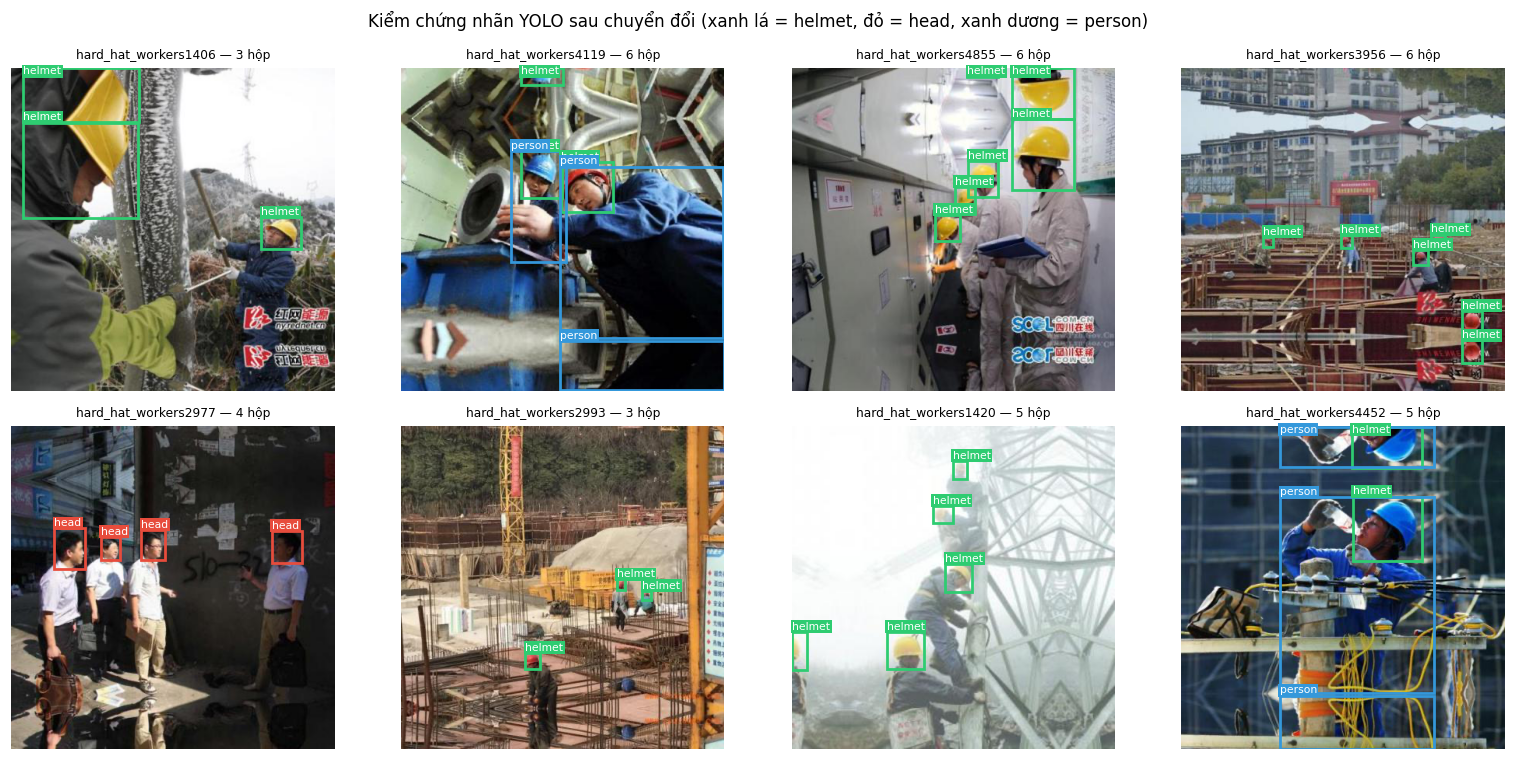

In [15]:
import matplotlib.patches as patches

PALETTE = {"helmet": "#2ecc71", "head": "#e74c3c", "person": "#3498db"}

def draw_yolo_labels(stem, split, ax):
    """Vẽ ảnh + hộp đọc ngược từ file nhãn YOLO (kiểm chứng chuyển đổi)."""
    img_path = next((YOLO_DIR / "images" / split).glob(f"{stem}.*"))
    lbl_path = YOLO_DIR / "labels" / split / f"{stem}.txt"
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    ax.imshow(img); ax.axis("off")
    n = 0
    for line in lbl_path.read_text().splitlines():
        if not line.strip():
            continue
        cid, cx, cy, w, h = line.split()
        cid, cx, cy, w, h = int(cid), *map(float, (cx, cy, w, h))
        # chuyển ngược về pixel để vẽ
        x0, y0 = (cx - w / 2) * W, (cy - h / 2) * H
        name = CLASS_NAMES[cid]
        ax.add_patch(patches.Rectangle((x0, y0), w * W, h * H, fill=False,
                                       edgecolor=PALETTE[name], lw=1.8))
        ax.text(x0, max(y0 - 3, 8), name, color="white", fontsize=7,
                bbox=dict(facecolor=PALETTE[name], edgecolor="none", pad=1))
        n += 1
    ax.set_title(f"{stem} — {n} hộp", fontsize=8)

rng = np.random.default_rng(SEED)
# chọn ảnh nhiều đối tượng cho dễ nhìn
busy = ann_df[ann_df["split"] == "train"].groupby("stem").size()
busy = busy[busy.between(3, 12)].index.tolist()
picks = rng.choice(busy, size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, stem in zip(axes.ravel(), picks):
    draw_yolo_labels(stem, "train", ax)
fig.suptitle("Kiểm chứng nhãn YOLO sau chuyển đổi (xanh lá = helmet, đỏ = head, xanh dương = person)",
             fontsize=11)
plt.savefig(ARTIFACT_DIR / "fig04_label_sanity_check.png", dpi=150, bbox_inches="tight")
plt.show()

Đây là lưới 8 ảnh thật, mỗi ảnh vẽ lại hộp đọc ngược từ chính file .txt đã ghi ra — không phải từ XML gốc. Soi từng ảnh:

- **4 ảnh đầu (hàng trên):** toàn hộp xanh lá `helmet`, cộng thêm hai hộp xanh dương `person` ở ảnh thứ hai (công nhân đang thao tác với ống lớn). Mọi hộp đều ôm sát đúng vành mũ bảo hộ màu vàng trên đầu — không hộp nào lệch ra ngoài hay chỉ trùm một phần.
- **Ảnh `hard_hat_workers2977` (đầu hàng dưới):** đây là ảnh đáng chú ý nhất trong lưới — 4 hộp đỏ `head` liên tiếp, đúng bốn công nhân đứng thành hàng đều không đội mũ bảo hộ. Hộp ôm sát đầu trần từng người, không chồng lấn nhau dù đứng cạnh nhau — minh hoạ trực quan đúng lớp mà hệ thống được xây để phát hiện.
- **Ảnh cuối cùng (`hard_hat_workers4452`, góc dưới-phải):** có hộp xanh dương `person` lồng bên ngoài hộp xanh lá `helmet` — một người đội mũ bảo hộ màu xanh dương, được gán đồng thời cả nhãn toàn thân lẫn nhãn cái mũ trên đầu. Đây là bằng chứng cho thấy ba lớp không loại trừ nhau về mặt không gian: một điểm ảnh có thể vừa nằm trong hộp `person`, vừa nằm trong hộp `helmet` — điều này cần nhớ khi diễn giải ma trận nhầm lẫn ở notebook 02, vì hai hộp lồng nhau dễ bị NMS xử lý nhầm nếu không phân biệt theo lớp.

**Kết luận kiểm chứng:** cả 8/8 ảnh đều cho hộp khớp đúng vị trí, đúng màu theo đúng lớp, không có dấu hiệu lệch trục hay hoán vị W/H đã liệt kê trong bảng chẩn đoán ở note trước. Bộ chuyển đổi VOC sang YOLO hoạt động đúng trên dữ liệu thật, không chỉ đúng trên một ví dụ tính tay.

## 7. Sinh `data.yaml` và kiểm tra tính toàn vẹn

In [16]:
yaml_path = du.write_data_yaml(DATA_YAML, YOLO_DIR, CLASS_NAMES)
print(f"Đã ghi: {yaml_path}\n")
print(yaml_path.read_text(encoding="utf-8"))

Đã ghi: /home/lablee/Documents/wm/configs/helmet.yaml

# Sinh tự động bởi notebooks/01_data_prep.ipynb — không sửa tay
path: /home/lablee/Documents/wm/data/yolo
train: images/train
val: images/val
test: images/test

nc: 3
names:
  0: helmet
  1: head
  2: person



In [17]:
verify = du.verify_dataset(YOLO_DIR)
display(verify)

problems = verify[["img_without_label", "label_without_img",
                   "bad_coord_lines", "bad_class_ids"]].to_numpy().sum()
if problems == 0:
    print("✔ Dữ liệu hợp lệ: ảnh và nhãn khớp 1-1, mọi toạ độ nằm trong [0,1], "
          "mọi class id hợp lệ.")
else:
    print(f"✘ Còn {problems} vấn đề — phải sửa trước khi train.")

,n_images,n_labels,img_without_label,label_without_img,bad_coord_lines,bad_class_ids
split,,,,,,
train,3501,3501,0,0,0,0
val,750,750,0,0,0,0
test,749,749,0,0,0,0


✔ Dữ liệu hợp lệ: ảnh và nhãn khớp 1-1, mọi toạ độ nằm trong [0,1], mọi class id hợp lệ.


Bốn cột lỗi đều **bằng 0 ở cả ba tập**, mỗi cột bắt một loại sự cố khác nhau:

| cột | bắt lỗi gì |
|---|---|
| `img_without_label` | ảnh không có file nhãn → ultralytics coi là ảnh nền, âm thầm sai |
| `label_without_img` | nhãn mồ côi, thường do symlink hỏng |
| `bad_coord_lines` | toạ độ ngoài `[0,1]` hoặc thiếu/thừa trường |
| `bad_class_ids` | class id ngoài `0..nc-1` |

Toàn bộ bằng 0 có một hệ quả nghe thì nhỏ nhưng rất quan trọng cho phần chấm *Phân tích*: **mọi lỗi quan sát được ở notebook 04 đều là lỗi của mô hình, không phải của dữ liệu.** Nếu nhãn bẩn thì không tài nào tách được hai nguồn lỗi này, và toàn bộ phần phân tích lỗi mất giá trị.

Cùng với `n_boxes_dropped = 0` ở §4, ta khẳng định được: **không một hộp nào bị mất trong quá trình chuyển đổi.**

## 8. Lưu bảng số liệu cho báo cáo

Các file dưới đây đưa thẳng vào mục *3. Dữ liệu* của báo cáo, và `ann_df` được notebook 04 dùng lại cho phân tích lỗi theo kích thước vật thể (khỏi phải đọc lại 5.000 file XML).

In [18]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
cls_tab.to_csv(ARTIFACT_DIR / "tab01_class_distribution.csv", encoding="utf-8-sig")
size_tab.to_csv(ARTIFACT_DIR / "tab02_size_distribution.csv", encoding="utf-8-sig")
split_summary.to_csv(ARTIFACT_DIR / "tab03_split_summary.csv", encoding="utf-8-sig")
verify.to_csv(ARTIFACT_DIR / "tab04_dataset_verification.csv", encoding="utf-8-sig")
ann_df.to_parquet(ARTIFACT_DIR / "annotations.parquet")   # dùng lại ở notebook 04

# lưu chính xác phép chia -> ai chạy lại cũng ra đúng tập test này
with open(ARTIFACT_DIR / "splits.json", "w", encoding="utf-8") as f:
    json.dump(split_stems, f, ensure_ascii=False)

with open(ARTIFACT_DIR / "environment.json", "w", encoding="utf-8") as f:
    json.dump(env, f, ensure_ascii=False, indent=2)

for p in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {p.name:<38} {p.stat().st_size/1024:8.1f} KB")

  annotations.parquet                       512.0 KB
  environment.json                            0.2 KB
  fig01_class_distribution.png               54.0 KB
  fig02_box_size_distribution.png            91.0 KB
  fig03_aspect_and_center.png               201.2 KB
  fig04_label_sanity_check.png             2283.4 KB
  splits.json                               116.1 KB
  tab01_class_distribution.csv                0.2 KB
  tab02_size_distribution.csv                 0.2 KB
  tab03_split_summary.csv                     0.1 KB
  tab04_dataset_verification.csv              0.2 KB


Danh sách file kèm dung lượng. Mỗi file có một mục đích rõ ràng:

| file | dùng ở đâu |
|---|---|
| `tab01`–`tab04` `.csv` | dán thẳng vào mục *3. Dữ liệu* của báo cáo |
| `fig01`–`fig04` `.png` | hình minh hoạ cho cùng mục đó |
| `annotations.parquet` | **notebook 02 và 04 đọc lại** thay vì parse lại 5.000 XML |
| `splits.json` | phép chia chính xác — ai chạy lại cũng ra đúng tập test này |
| `environment.json` | bằng chứng môi trường cho phụ lục |

Định dạng `utf-8-sig` cho CSV là chi tiết nhỏ nhưng thiết thực: thiếu BOM thì Excel hiển thị tiếng Việt thành ký tự rác.

`splits.json` đáng chú ý nhất. Phép chia đã tất định nhờ seed, nhưng lưu ra file là **lớp bảo hiểm thứ hai**: nếu sau này ai đó lỡ sửa hàm phân tầng, ta vẫn khôi phục được đúng tập test đã dùng để báo cáo — và không rơi vào tình huống "số liệu không khớp giữa báo cáo và log" mà đề bài xử như gian lận học thuật.